<a href="https://colab.research.google.com/github/ampereapescador/Metodos2PereaPescador/blob/main/T5_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

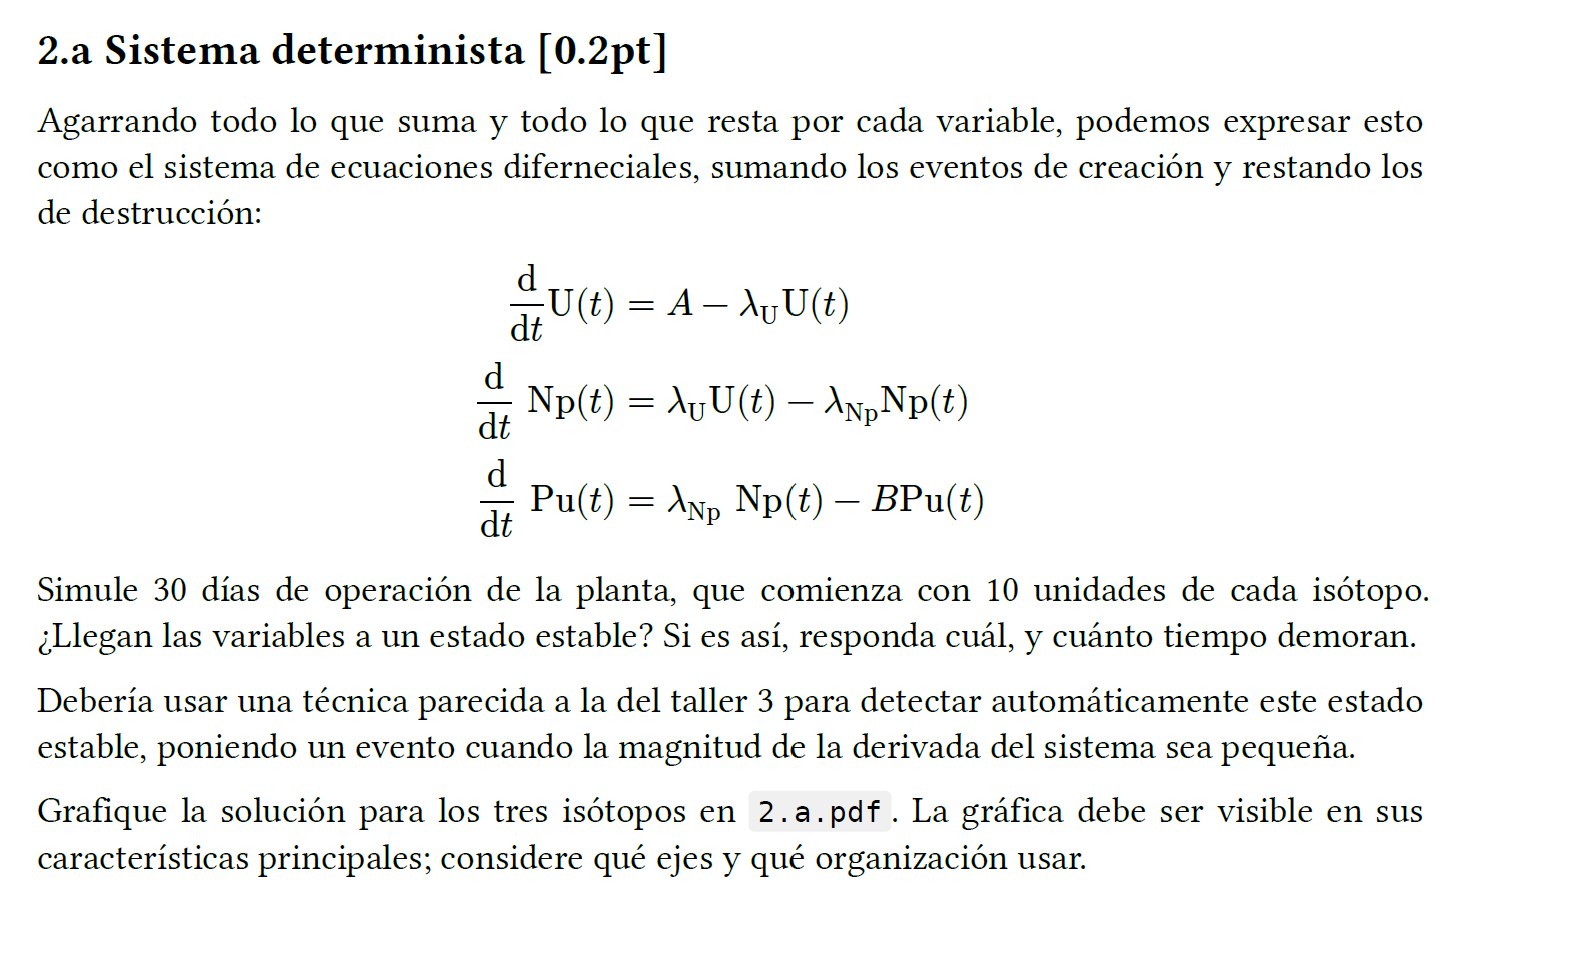

Generado/content/sample_data/2.a.pdf


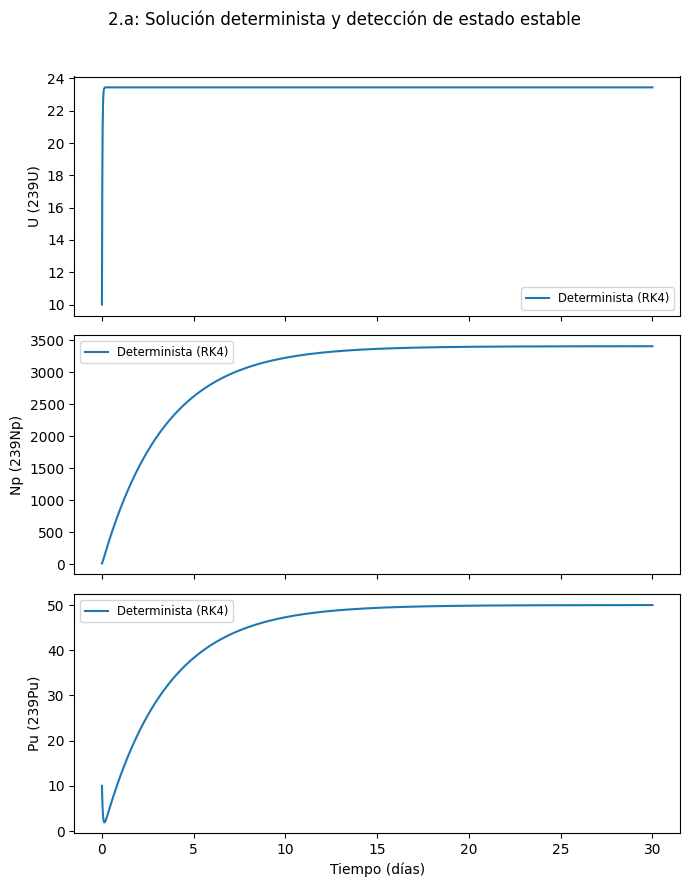

In [15]:
# 2a.py - Sistema determinista

import numpy as np, matplotlib.pyplot as plt
from math import log

# Parámetros del enunciado y ecuaciones
A = 1000.0; B = 20.0
t12_U_days = 23.4 / 1440.0
t12_Np_days = 2.36
lambda_U = np.log(2) / t12_U_days
lambda_Np = np.log(2) / t12_Np_days
tmax = 30.0
U0 = 10.0; Np0 = 10.0; Pu0 = 10.0
dt = 0.01
time_grid = np.arange(0, tmax+dt, dt)

#Funciones

def f_det(y):
    U, Np, Pu = y
    return np.array([A - lambda_U*U, lambda_U*U - lambda_Np*Np, lambda_Np*Np - B*Pu])

def integrate_rk4(y0, tgrid, f):
    y = np.zeros((len(tgrid), len(y0)))
    y[0] = y0
    for i in range(len(tgrid)-1):
        h = tgrid[i+1]-tgrid[i]
        k1 = f(y[i])
        k2 = f(y[i] + 0.5*h*k1)
        k3 = f(y[i] + 0.5*h*k2)
        k4 = f(y[i] + h*k3)
        y[i+1] = y[i] + (h/6.0)*(k1 + 2*k2 + 2*k3 + k4)
    return y

y_det = integrate_rk4(np.array([U0,Np0,Pu0]), time_grid, f_det)

# Aproximación a estado estable, derivando
deriv = np.gradient(y_det, axis=0) / dt
deriv_norm = np.linalg.norm(deriv, axis=1)
threshold = 1e-3
idx = np.where(deriv_norm < threshold)[0]
t_stable = None
if idx.size>0:
    t_stable = time_grid[idx[0]]

labels = ['U (239U)', 'Np (239Np)', 'Pu (239Pu)']
fig, axes = plt.subplots(3,1, figsize=(7,9), sharex=True)
for j in range(3):
    axes[j].plot(time_grid, y_det[:,j], label='Determinista (RK4)')
    axes[j].set_ylabel(labels[j])
    axes[j].legend(fontsize='small')
if t_stable is not None:
    axes[0].axvline(t_stable, color='k', linestyle='--')
    axes[0].text(t_stable, max(y_det[:,0])*0.8, f"t_estable ≈ {t_stable:.2f} d", rotation=90, va='center')
axes[-1].set_xlabel('Tiempo (días)')
plt.suptitle('2.a: Solución determinista y detección de estado estable')
plt.tight_layout(rect=[0,0,1,0.96])
plt.savefig('/content/sample_data/2a.pdf', dpi=150)
print('Generado/content/sample_data/2.a.pdf')

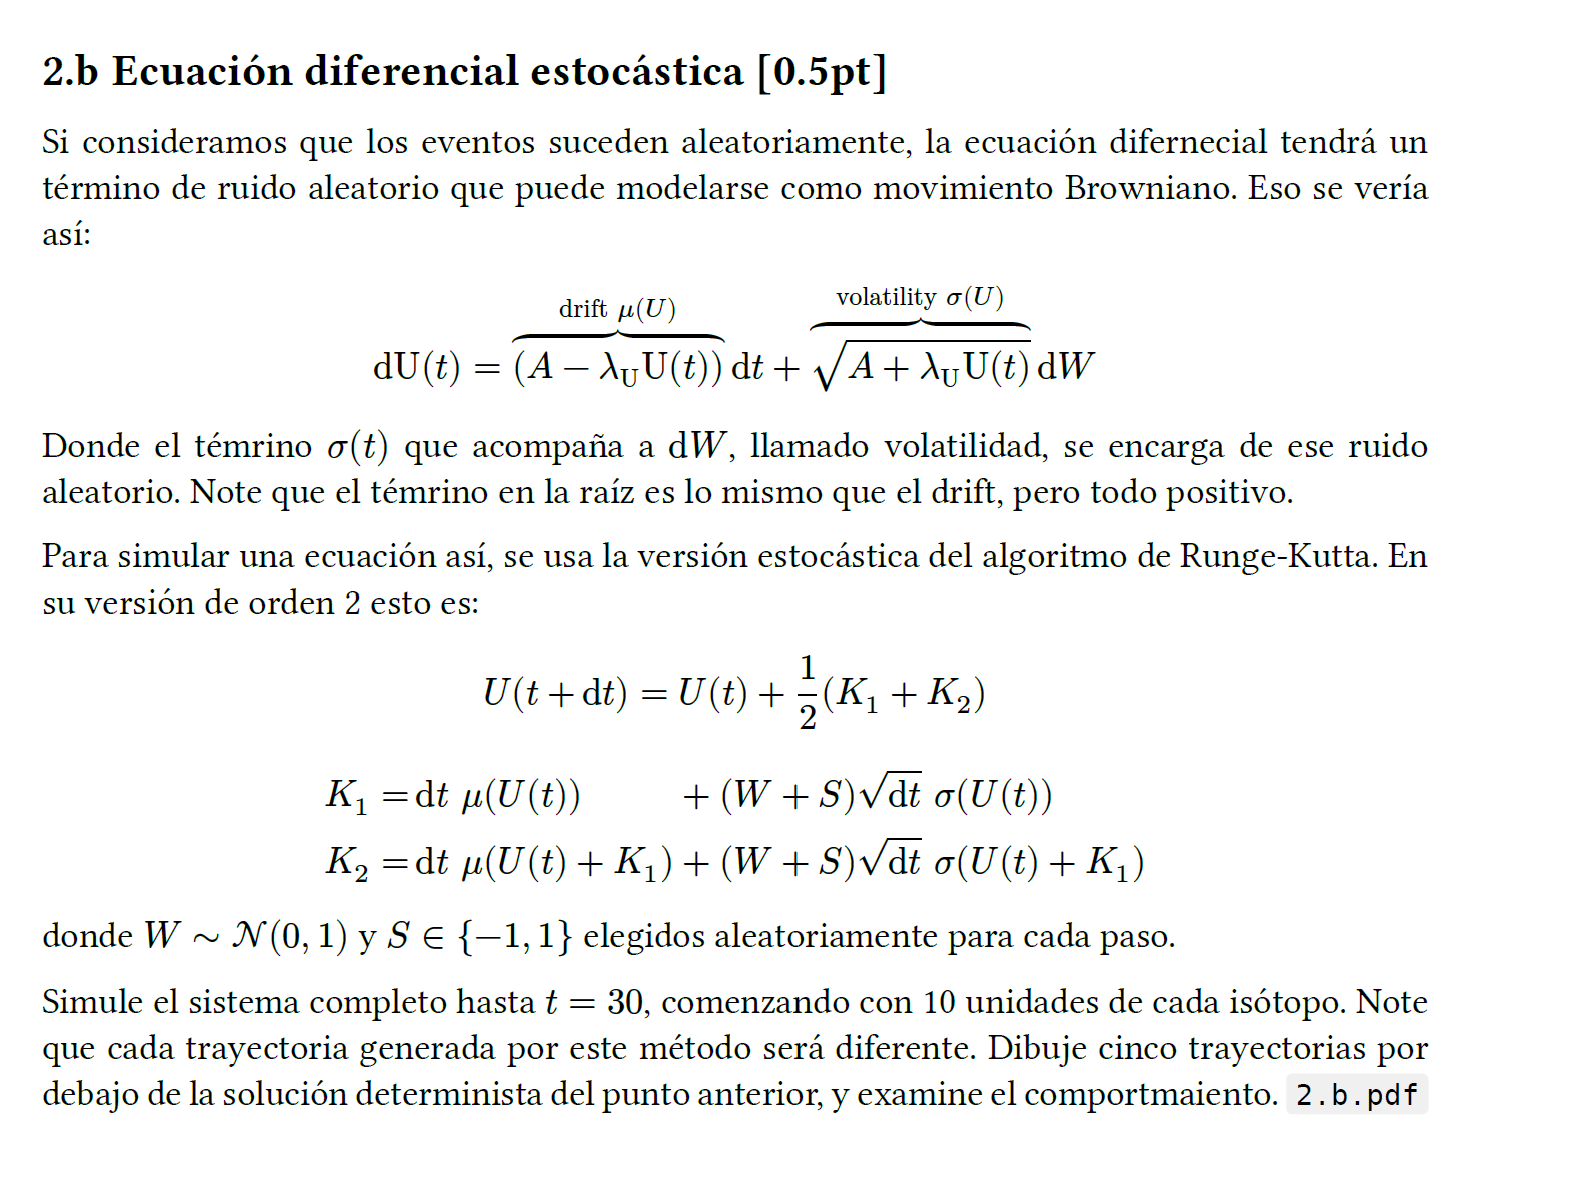

Generado /content/sample_data/2.b.pdf


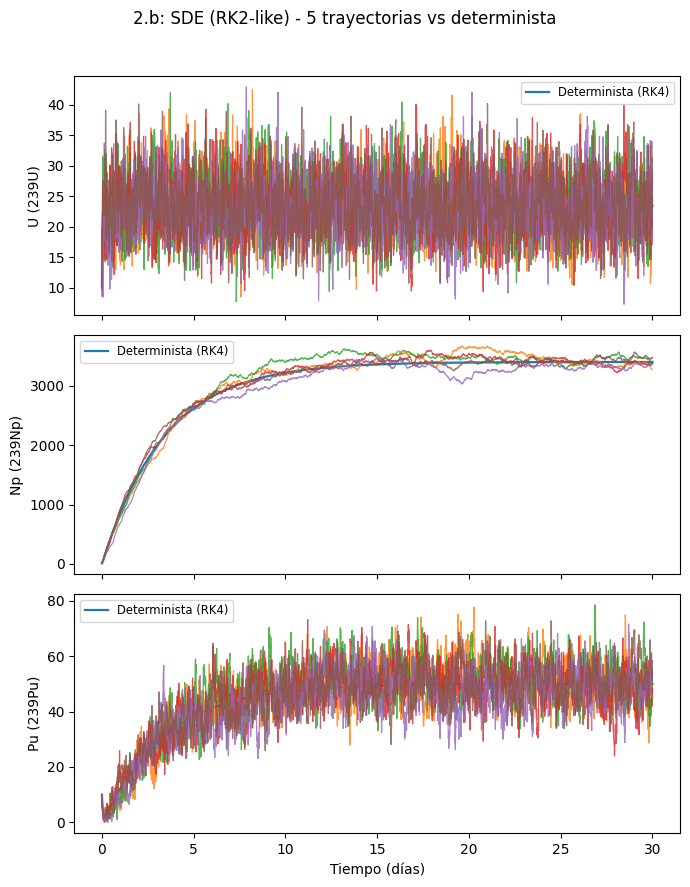

In [7]:
# 2b Ecuacion Diferencial Estocástica - SDE RK2-like
import numpy as np, matplotlib.pyplot as plt, random
from math import log

# Parámetros
A = 1000.0; B = 20.0
t12_U_days = 23.4 / 1440.0
t12_Np_days = 2.36
lambda_U = np.log(2) / t12_U_days
lambda_Np = np.log(2) / t12_Np_days
tmax = 30.0
U0 = 10.0; Np0 = 10.0; Pu0 = 10.0
dt = 0.01
time_grid = np.arange(0, tmax+dt, dt)

#Funciones

def f_det(y):
    U, Np, Pu = y
    return np.array([A - lambda_U*U, lambda_U*U - lambda_Np*Np, lambda_Np*Np - B*Pu])
def integrate_rk4(y0, tgrid, f):
    y = np.zeros((len(tgrid), len(y0)))
    y[0] = y0
    for i in range(len(tgrid)-1):
        h = tgrid[i+1]-tgrid[i]
        k1 = f(y[i])
        k2 = f(y[i] + 0.5*h*k1)
        k3 = f(y[i] + 0.5*h*k2)
        k4 = f(y[i] + h*k3)
        y[i+1] = y[i] + (h/6.0)*(k1 + 2*k2 + 2*k3 + k4)
    return y

y_det = integrate_rk4(np.array([U0,Np0,Pu0]), time_grid, f_det)

def vol_U(U): return np.sqrt(max(A + lambda_U*U, 0.0))
def vol_Np(U, Np): return np.sqrt(max(lambda_U*U + lambda_Np*Np, 0.0))
def vol_Pu(Np, Pu): return np.sqrt(max(lambda_Np*Np + B*Pu, 0.0))

def sde_rk2_trajectory(seed=None):
    if seed is not None:
        np.random.seed(seed); random.seed(seed+1)
    U, Np, Pu = U0, Np0, Pu0
    traj = np.zeros((len(time_grid),3))
    traj[0] = [U,Np,Pu]
    for i in range(len(time_grid)-1):
        h = time_grid[i+1]-time_grid[i]; sqrt_h = np.sqrt(h)
        WU, WNp, WPu = np.random.normal(), np.random.normal(), np.random.normal()
        S1 = random.choice([-1,1]); S2 = random.choice([-1,1])
        muU = A - lambda_U*U
        muNp = lambda_U*U - lambda_Np*Np
        muPu = lambda_Np*Np - B*Pu
        K1_U = h*muU + (WU + S1)*sqrt_h*vol_U(U)
        K1_Np = h*muNp + (WNp + S1)*sqrt_h*vol_Np(U,Np)
        K1_Pu = h*muPu + (WPu + S1)*sqrt_h*vol_Pu(Np,Pu)
        U1 = U + K1_U; Np1 = Np + K1_Np; Pu1 = Pu + K1_Pu
        WU2, WNp2, WPu2 = np.random.normal(), np.random.normal(), np.random.normal()
        K2_U = h*(A - lambda_U*U1) + (WU2 + S2)*sqrt_h*vol_U(U1)
        K2_Np = h*(lambda_U*U1 - lambda_Np*Np1) + (WNp2 + S2)*sqrt_h*vol_Np(U1,Np1)
        K2_Pu = h*(lambda_Np*Np1 - B*Pu1) + (WPu2 + S2)*sqrt_h*vol_Pu(Np1,Pu1)
        U = max(U + 0.5*(K1_U + K2_U), 0.0)
        Np = max(Np + 0.5*(K1_Np + K2_Np), 0.0)
        Pu = max(Pu + 0.5*(K1_Pu + K2_Pu), 0.0)
        traj[i+1] = [U,Np,Pu]
    return traj

sde_trajs = [sde_rk2_trajectory(seed=100+i) for i in range(5)]

labels = ['U (239U)', 'Np (239Np)', 'Pu (239Pu)']
fig, axes = plt.subplots(3,1, figsize=(7,9), sharex=True)
for j in range(3):
    axes[j].plot(time_grid, y_det[:,j], label='Determinista (RK4)', linewidth=1.6)
    for k in range(5):
        axes[j].plot(time_grid, sde_trajs[k][:,j], linewidth=0.9, alpha=0.8)
    axes[j].set_ylabel(labels[j])
    axes[j].legend(fontsize='small')
axes[-1].set_xlabel('Tiempo (días)')
plt.suptitle('2.b: SDE (RK2-like) - 5 trayectorias vs determinista')
plt.tight_layout(rect=[0,0,1,0.96])
plt.savefig('/content/sample_data/2.b.pdf', dpi=150)
print('Generado /content/sample_data/2.b.pdf')

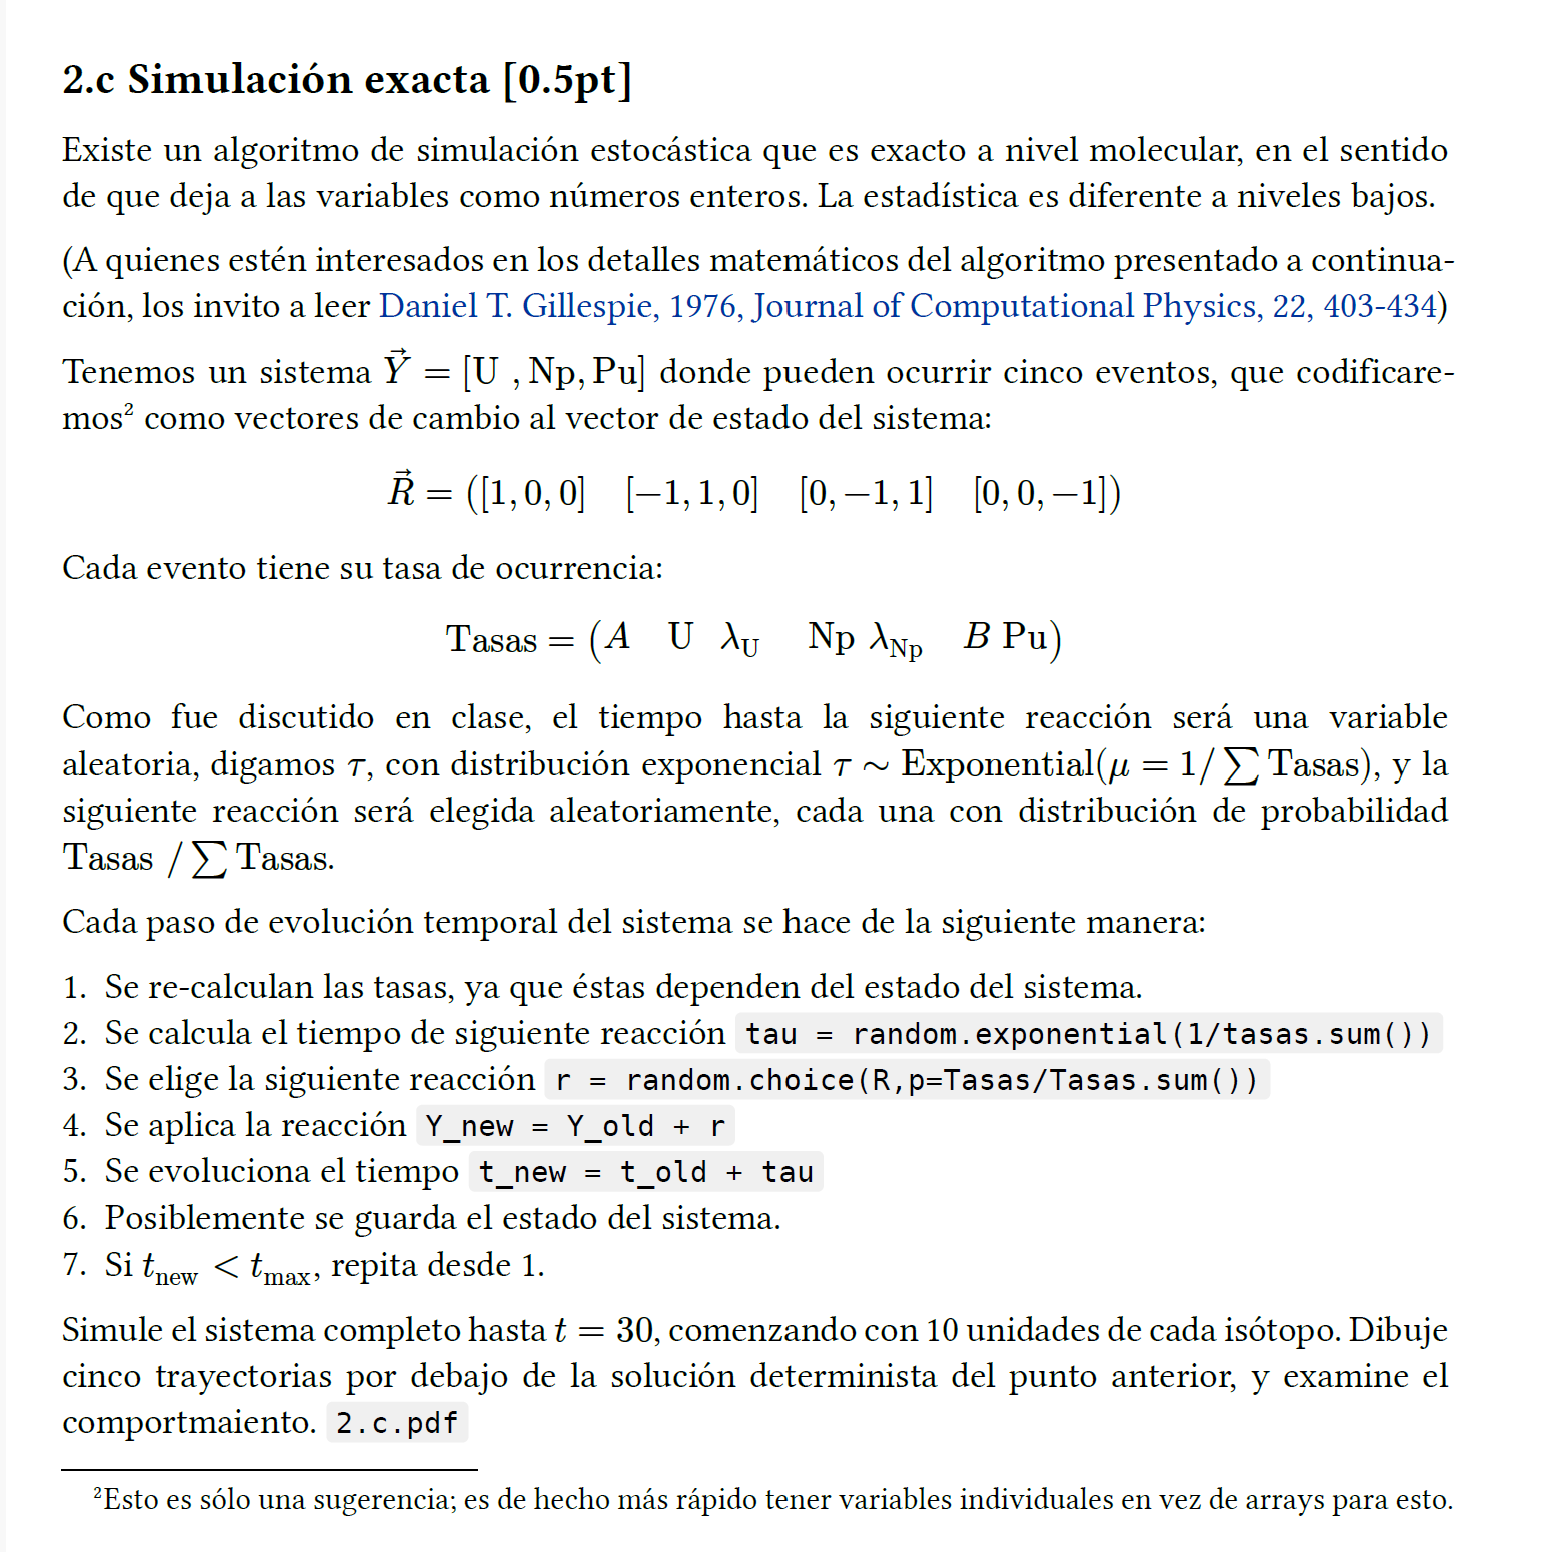

Generado /content/sample_data/2.c.pdf


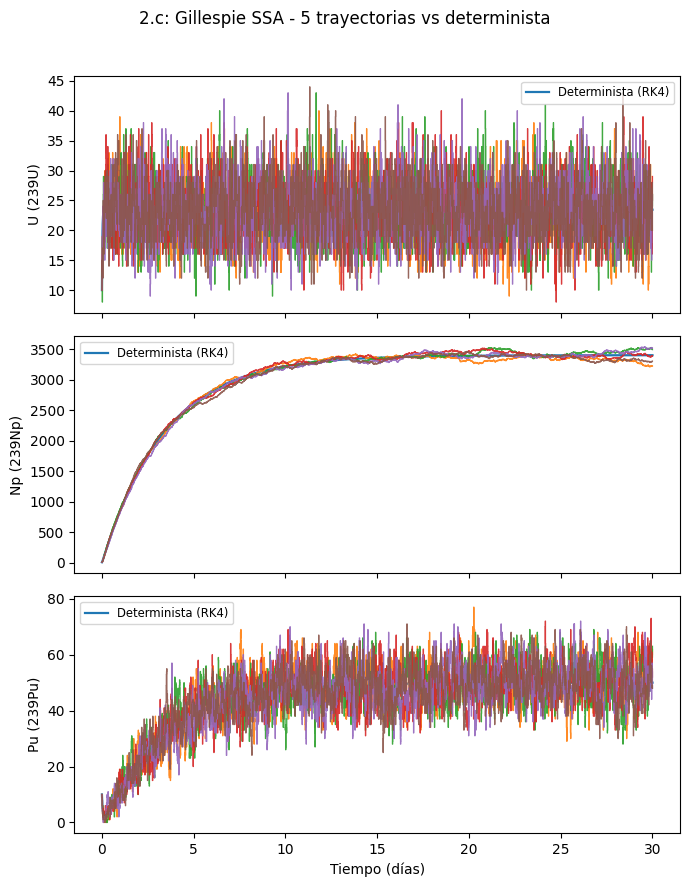

In [6]:
# 2c Simulación exacta- Gillespie
import numpy as np, matplotlib.pyplot as plt, random
from math import log

# Parámetros
A = 1000.0; B = 20.0
t12_U_days = 23.4 / 1440.0
t12_Np_days = 2.36
lambda_U = np.log(2) / t12_U_days
lambda_Np = np.log(2) / t12_Np_days
tmax = 30.0
U0 = 10; Np0 = 10; Pu0 = 10
dt = 0.01
time_grid = np.arange(0, tmax+dt, dt)

def f_det(y):
    U, Np, Pu = y
    return np.array([A - lambda_U*U, lambda_U*U - lambda_Np*Np, lambda_Np*Np - B*Pu])
def integrate_rk4(y0, tgrid, f):
    y = np.zeros((len(tgrid), len(y0)))
    y[0] = y0
    for i in range(len(tgrid)-1):
        h = tgrid[i+1]-tgrid[i]
        k1 = f(y[i])
        k2 = f(y[i] + 0.5*h*k1)
        k3 = f(y[i] + 0.5*h*k2)
        k4 = f(y[i] + h*k3)
        y[i+1] = y[i] + (h/6.0)*(k1 + 2*k2 + 2*k3 + k4)
    return y

y_det = integrate_rk4(np.array([U0,Np0,Pu0]), time_grid, f_det)

R = np.array([[1,0,0], [-1,1,0], [0,-1,1], [0,0,-1]])
def gillespie_traj_to_grid(seed=None):
    if seed is not None:
        np.random.seed(seed); random.seed(seed+1)
    t=0.0; U=int(U0); Np=int(Np0); Pu=int(Pu0)
    times=[0.0]; states=[np.array([U,Np,Pu], dtype=float)]
    while t < tmax:
        tasas = np.array([A, U*lambda_U, Np*lambda_Np, Pu*B])
        s = tasas.sum()
        if s <= 0: break
        tau = np.random.exponential(1.0/s)
        r = np.random.choice(4, p=tasas/s)
        change = R[r]
        U += int(change[0]); Np += int(change[1]); Pu += int(change[2])
        U, Np, Pu = max(U,0), max(Np,0), max(Pu,0)
        t += tau
        times.append(t); states.append(np.array([U,Np,Pu], dtype=float))
    traj = np.zeros((len(time_grid),3)); idx=0
    for i,tt in enumerate(time_grid):
        while idx+1 < len(times) and times[idx+1] <= tt:
            idx += 1
        traj[i] = states[idx]
    return traj

gill_trajs = [gillespie_traj_to_grid(seed=200+i) for i in range(5)]

labels = ['U (239U)', 'Np (239Np)', 'Pu (239Pu)']
fig, axes = plt.subplots(3,1, figsize=(7,9), sharex=True)
for j in range(3):
    axes[j].plot(time_grid, y_det[:,j], label='Determinista (RK4)', linewidth=1.6)
    for k in range(5):
        axes[j].step(time_grid, gill_trajs[k][:,j], where='post', linewidth=0.9, alpha=0.9)
    axes[j].set_ylabel(labels[j])
    axes[j].legend(fontsize='small')
axes[-1].set_xlabel('Tiempo (días)')
plt.suptitle('2.c: Gillespie SSA - 5 trayectorias vs determinista')
plt.tight_layout(rect=[0,0,1,0.96])
plt.savefig('/content/sample_data/2.c.pdf', dpi=150)
print('Generado /content/sample_data/2.c.pdf')

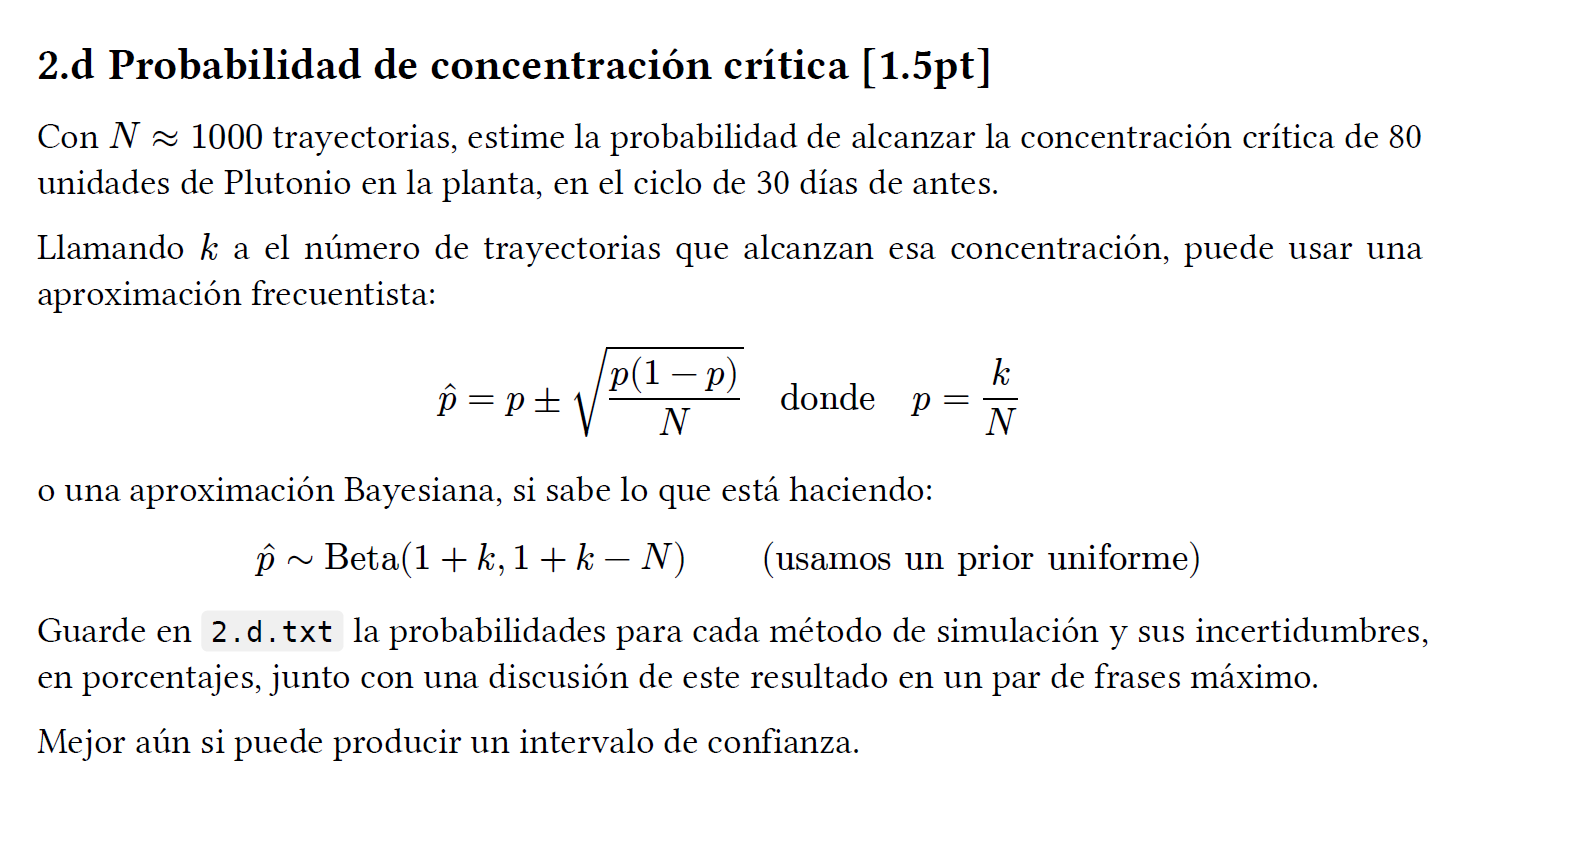

In [13]:
# 2d Probabilidad de concentración

# Simulación de Monte Carlo (MCMC/Gillespie) para estimar la probabilidad de que la cantidad de Plutonio (Pu) exceda un umbral crítico dado.

# Parámetros principales:
#   N          : número de simulaciones independientes.
#   threshold  : umbral crítico de Pu.
#   A          : tasa de producción de U por bombardeo de neutrones.
#   B          : tasa de extracción de Pu.
#   t1/2(U)    : vida media del Uranio-239.
#   t1/2(Np)   : vida media del Neptunio-239.
#
# Ecuaciones:
#   λ = ln(2) / t1/2   → constante de decaimiento.
#   Intervalo de confianza 95% para p_hat:
#       IC = [ p_hat - 1.96*σ , p_hat + 1.96*σ ]
#       con σ = sqrt( p_hat * (1 - p_hat) / N )
#
# Bayes:
#   Prior Beta(1,1). Posterior ~ Beta(k+1, N-k+1)
#   Media Bayesiana = (k+1) / (N+2)

import numpy as np
import argparse
import sys

# Gillespie una trayectoria
def simulate_once(A, B, lamU, lamNp, threshold, T_max=100):
    U, Np, Pu = 0, 0, 0
    t = 0
    while t < T_max:
        rates = [A, lamU*U, lamNp*Np, B*Pu]
        total = sum(rates)
        if total <= 0:
            break
        dt = np.random.exponential(1/total)
        t += dt
        r = np.random.rand() * total
        if r < rates[0]:
            U += 1
        elif r < rates[0] + rates[1]:
            U -= 1; Np += 1
        elif r < rates[0] + rates[1] + rates[2]:
            Np -= 1; Pu += 1
        else:
            Pu = max(Pu-1, 0)
        if Pu >= threshold:
            return True
    return False

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--N", type=int, default=500, help="Número de simulaciones")
    parser.add_argument("--threshold", type=int, default=20, help="Umbral crítico de Pu")
    parser.add_argument("--out", type=str, default="2.d.txt", help="Archivo de salida")
    parser.add_argument("--seed", type=int, default=42, help="Semilla aleatoria")
    parser.add_argument("--dt", type=float, default=1.0, help="Paso de tiempo máximo")
    args, _ = parser.parse_known_args()

    np.random.seed(args.seed)

    # parámetros físicos
    A = 5.0
    B = 0.1
    t_half_U, t_half_Np = 23.5, 2.36  # días
    lamU = np.log(2) / t_half_U
    lamNp = np.log(2) / t_half_Np

    # simulaciones
    successes = sum(simulate_once(A, B, lamU, lamNp, args.threshold) for _ in range(args.N))
    p_hat = successes / args.N

    # intervalo de confianza clásico
    sigma = np.sqrt(p_hat * (1 - p_hat) / args.N)
    ci_low, ci_high = p_hat - 1.96*sigma, p_hat + 1.96*sigma

    # estimador Bayesiano
    bayes_mean = (successes + 1) / (args.N + 2)

    # guardar resultados
    with open(args.out, "w") as f:
        f.write("Resultados de simulación Monte Carlo (2d)\n")
        f.write(f"Simulaciones N = {args.N}\n")
        f.write(f"Umbral Pu = {args.threshold}\n")
        f.write(f"Éxitos (Pu ≥ threshold) = {successes}\n")
        f.write(f"p_hat = {p_hat:.4f}\n")
        f.write(f"IC 95% clásico = [{ci_low:.4f}, {ci_high:.4f}]\n")
        f.write(f"Media Bayesiana = {bayes_mean:.4f}\n")

if __name__ == "__main__":
    main()
